# 1D Heavy-Tailed (Student-t) DDPM 실험

## 0. 셋업 & 설정

In [1]:
%load_ext autoreload
%autoreload 2

import os, sys, time

sys.path.insert(0, os.path.abspath("."))

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy import stats

import t_diffusion as td

import matplotlib.font_manager as fm
_have = {f.name for f in fm.fontManager.ttflist}
KFONT = next((f for f in ["Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans KR"]
              if f in _have), None)
KO = {"fontname": KFONT} if KFONT else {}
print("한글 폰트 =", KFONT)

NU_DATA = 3.0                              # dof of the data distribution
NU_MODEL = [3.0, 10.0, 30.0, 50.0, 100.0, 500.0]  # dof of the diffusion noise
LOC, SCALE = 0.0, 1.0
N_TOTAL, N_TRAIN = 50000, 10000
T = 1000
STEPS, BATCH, LR, HIDDEN = 20000, 128, 1e-3, 128
N_SAMPLE = 20000
SEED = 0
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("device =", DEVICE, "| steps =", STEPS, "| n_sample =", N_SAMPLE)

한글 폰트 = NanumGothic
device = cuda | steps = 20000 | n_sample = 20000


## 1. 데이터

In [2]:
def make_data():
    rng = np.random.default_rng(SEED)
    pool = stats.t.rvs(df=NU_DATA, loc=LOC, scale=SCALE, size=N_TOTAL, random_state=rng)
    idx = rng.permutation(N_TOTAL)
    return pool[idx[:N_TRAIN]], pool[idx[N_TRAIN:]]

train_np, held = make_data()
x0 = torch.tensor(train_np, dtype=torch.float32).unsqueeze(-1)

print(f"data ~ t(nu={NU_DATA:g}, loc={LOC:g}, scale={SCALE:g})")
print(f"pool {N_TOTAL} | train {N_TRAIN} "
      f"(min {train_np.min():.2f}, max {train_np.max():.2f}) | held-out {len(held)}")

data ~ t(nu=3, loc=0, scale=1)
pool 50000 | train 10000 (min -15.43, max 43.62) | held-out 40000


## 2. 평가 지표

In [3]:
def evaluate(gen, held):
    gen = np.asarray(gen, dtype=np.float64)
    finite = np.isfinite(gen)
    out = {"n_nonfinite": int((~finite).sum())}
    g = gen[finite]

    ks = stats.kstest(g, "t", args=(NU_DATA, LOC, SCALE))
    out["ks_stat_vs_true_t"] = float(ks.statistic)
    out["ks_pval_vs_true_t"] = float(ks.pvalue)

    ks2 = stats.ks_2samp(g, held)
    out["ks_stat_vs_heldout"] = float(ks2.statistic)
    out["ks_pval_vs_heldout"] = float(ks2.pvalue)
    out["w1_vs_heldout"] = float(stats.wasserstein_distance(g, held))

    df_hat, loc_hat, sc_hat = stats.t.fit(g)
    out["mle_df"], out["mle_loc"], out["mle_scale"] = float(df_hat), float(loc_hat), float(sc_hat)

    levels = [0.001, 0.01, 0.05, 0.5, 0.95, 0.99, 0.999]
    out["quantile_levels"] = levels
    out["quantiles_gen"] = [float(np.quantile(g, q)) for q in levels]
    out["quantiles_true"] = [float(stats.t.ppf(q, NU_DATA, LOC, SCALE)) for q in levels]
    for thr in (3, 5, 10):
        out[f"P(|x|>{thr})_gen"] = float(np.mean(np.abs(g) > thr))
        out[f"P(|x|>{thr})_true"] = float(2 * stats.t.sf(thr, NU_DATA, LOC, SCALE))

    a = np.sort(np.abs(g))[::-1]
    k = max(10, int(0.1 * len(a)))
    a = a[: k + 1]
    out["hill_tail_index"] = float(1.0 / np.mean(np.log(a[:k] / a[k]))) if a[k] > 0 else float("nan")

    out["median"] = float(np.median(g))
    out["iqr"] = float(np.subtract(*np.percentile(g, [75, 25])))
    return out

## 3. nu 를 바꿔가며 학습 + 샘플링

In [4]:
results, gens = {}, {}
t_all = time.time()

for i, nu in enumerate(NU_MODEL, 1):
    tag = f"nu={nu:g}"
    t0 = time.time()
    print(f"[{i}/{len(NU_MODEL)}] {tag:>9}  training ... ", end="", flush=True)

    model, sch = td.train(x0, nu, T=T, steps=STEPS, batch=BATCH, lr=LR,
                          hidden=HIDDEN, device=DEVICE, seed=SEED)
    g = td.sample(model, sch, nu, n=N_SAMPLE, device=DEVICE, seed=SEED)
    g = g.numpy().astype(np.float64)

    gens[tag] = g

    m = evaluate(g, held)
    m["train_seconds"] = round(time.time() - t0, 1)
    results[tag] = m

    print(f"KS {m['ks_stat_vs_true_t']:.4f} | MLEdof {m['mle_df']:5.2f} | "
          f"Hill {m['hill_tail_index']:5.2f} | {m['train_seconds']:.1f}s")

print(f"done: {len(results)} models in {time.time() - t_all:.1f}s")

[1/6]      nu=3  training ... KS 0.0753 | MLEdof  2.69 | Hill  2.05 | 112.9s
[2/6]     nu=10  training ... KS 0.0166 | MLEdof  3.06 | Hill  2.37 | 65.0s
[3/6]     nu=30  training ... KS 0.0169 | MLEdof  2.89 | Hill  2.54 | 54.8s
[4/6]     nu=50  training ... KS 0.0207 | MLEdof  2.79 | Hill  2.58 | 101.7s
[5/6]    nu=100  training ... KS 0.0219 | MLEdof  2.72 | Hill  2.58 | 104.1s
[6/6]    nu=500  training ... KS 0.0239 | MLEdof  2.70 | Hill  2.58 | 103.7s
done: 6 models in 542.3s


## 4. 결과 표

In [5]:
hdr = (f"{'model':>10} {'KS(true)':>9} {'p':>9} {'KS(held)':>9} {'W1':>8} "
       f"{'MLEdof':>7} {'Hill':>6} {'q99.9':>8} {'P|x|>5':>8}")
print(hdr)
print("-" * len(hdr))
for k, m in results.items():
    print(f"{k:>10} {m['ks_stat_vs_true_t']:9.4f} {m['ks_pval_vs_true_t']:9.3g} "
          f"{m['ks_stat_vs_heldout']:9.4f} {m['w1_vs_heldout']:8.4f} "
          f"{m['mle_df']:7.2f} {m['hill_tail_index']:6.2f} "
          f"{m['quantiles_gen'][-1]:8.2f} {m['P(|x|>5)_gen']:8.4f}")

ref = results[next(iter(results))]
print(f"{'TRUE':>10} {'-':>9} {'-':>9} {'-':>9} {'-':>8} "
      f"{NU_DATA:7.2f} {NU_DATA:6.2f} {ref['quantiles_true'][-1]:8.2f} "
      f"{2 * stats.t.sf(5, NU_DATA, LOC, SCALE):8.4f}")

     model  KS(true)         p  KS(held)       W1  MLEdof   Hill    q99.9   P|x|>5
----------------------------------------------------------------------------------
      nu=3    0.0753   4.8e-99    0.0738   0.2477    2.69   2.05     6.49   0.0140
     nu=10    0.0166   3.4e-05    0.0171   0.0677    3.06   2.37     8.02   0.0170
     nu=30    0.0169  2.24e-05    0.0184   0.0901    2.89   2.54     8.60   0.0173
     nu=50    0.0207  6.73e-08    0.0215   0.1039    2.79   2.58     8.85   0.0169
    nu=100    0.0219  9.03e-09    0.0220   0.1087    2.72   2.58     9.36   0.0175
    nu=500    0.0239  2.56e-10    0.0242   0.1174    2.70   2.58     9.95   0.0179
      TRUE         -         -         -        -    3.00   3.00    10.21   0.0154


## 5. 플롯

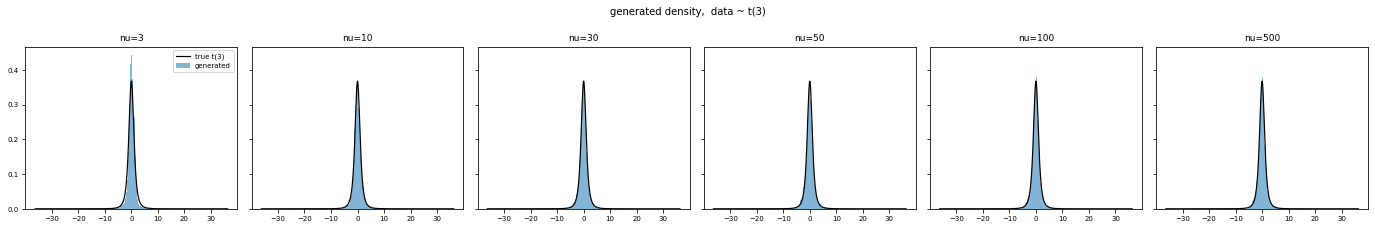

In [6]:
keys = list(gens)
ncol = len(keys)

fig, axes = plt.subplots(1, ncol, figsize=(3.2 * ncol, 3.2), sharey=True)
axes = np.atleast_1d(axes)
lim = max(float(np.abs(np.concatenate([gens[k] for k in keys])).max()), 12.0)
grid = np.linspace(-lim, lim, 2000)
for ax, k in zip(axes, keys):
    ax.hist(gens[k], bins=120, density=True, alpha=0.55, label="generated")
    ax.plot(grid, stats.t.pdf(grid, NU_DATA, LOC, SCALE), "k-", lw=1.2,
            label=f"true t({NU_DATA:g})")
    ax.set_title(k, fontsize=9)
    ax.tick_params(labelsize=7)
axes[0].legend(fontsize=7)
fig.suptitle(f"generated density,  data ~ t({NU_DATA:g})", fontsize=10)
fig.tight_layout()
plt.show()

### 5-1. 밀도 (log y)

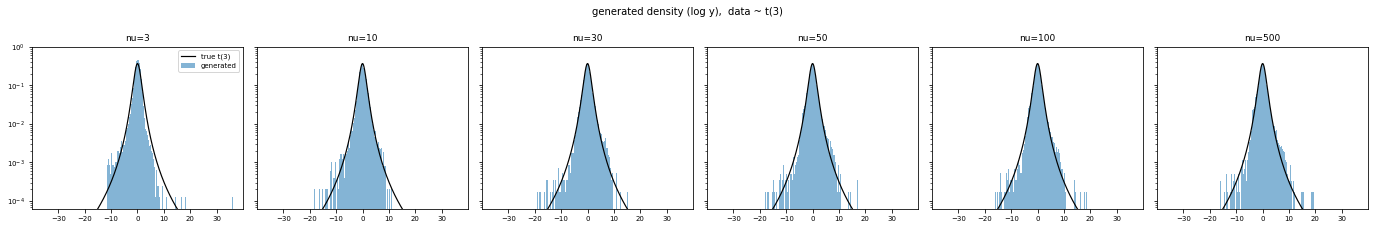

In [7]:
BINS = 120

keys = list(gens)
ncol = len(keys)

floor = min(1.0 / (len(gens[k]) * (np.ptp(gens[k]) / BINS)) for k in keys) / 2

fig, axes = plt.subplots(1, ncol, figsize=(3.2 * ncol, 3.2), sharey=True)
axes = np.atleast_1d(axes)
for ax, k in zip(axes, keys):
    ax.hist(gens[k], bins=BINS, density=True, alpha=0.55, label="generated")
    ax.plot(grid, stats.t.pdf(grid, NU_DATA, LOC, SCALE), "k-", lw=1.2,
            label=f"true t({NU_DATA:g})")
    ax.set_yscale("log")
    ax.set_ylim(floor, 1)
    ax.set_title(k, fontsize=9)
    ax.tick_params(labelsize=7)
axes[0].legend(fontsize=7)
fig.suptitle(f"generated density (log y),  data ~ t({NU_DATA:g})", fontsize=10)
fig.tight_layout()
plt.show()

### 5-2. 밀도 (log y, ±12 고정)

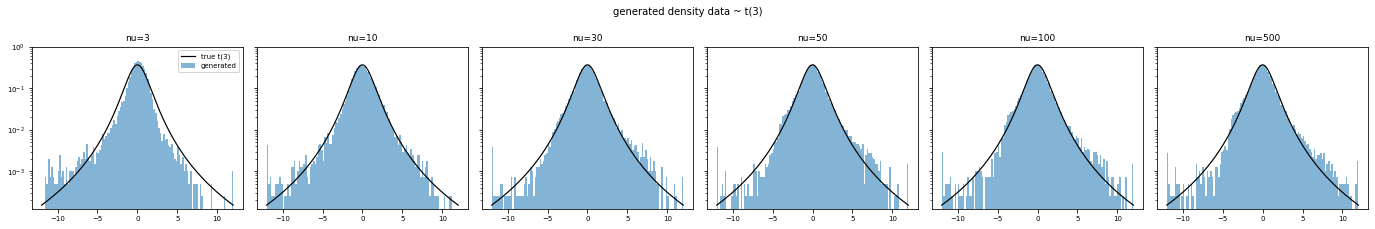

In [8]:
BINS = 120
LIM = 12.0                              # 클리핑/축 범위 (고정 창)
grid_lim = np.linspace(-LIM, LIM, 2000)  # 이론 pdf 곡선용 격자

floor = 1.0 / (len(gens[keys[0]]) * (2 * LIM / BINS)) / 2

fig, axes = plt.subplots(1, ncol, figsize=(3.2 * ncol, 3.2), sharey=True, sharex=True)
axes = np.atleast_1d(axes)
for ax, k in zip(axes, keys):
    a = np.asarray(gens[k], dtype=np.float64)
    ax.hist(np.clip(a, -LIM, LIM), bins=BINS, range=(-LIM, LIM),
            density=True, alpha=0.55, label="generated")
    ax.plot(grid_lim, stats.t.pdf(grid_lim, NU_DATA, LOC, SCALE), "k-", lw=1.2,
            label=f"true t({NU_DATA:g})")
    ax.set_yscale("log")
    ax.set_ylim(floor, 1)
    ax.set_title(k, fontsize=9)
    ax.tick_params(labelsize=7)
axes[0].legend(fontsize=7)
fig.suptitle(f"generated density data ~ t({NU_DATA:g})",
             fontsize=10)
fig.tight_layout()
plt.show()

### 5-3. Q-Q plot

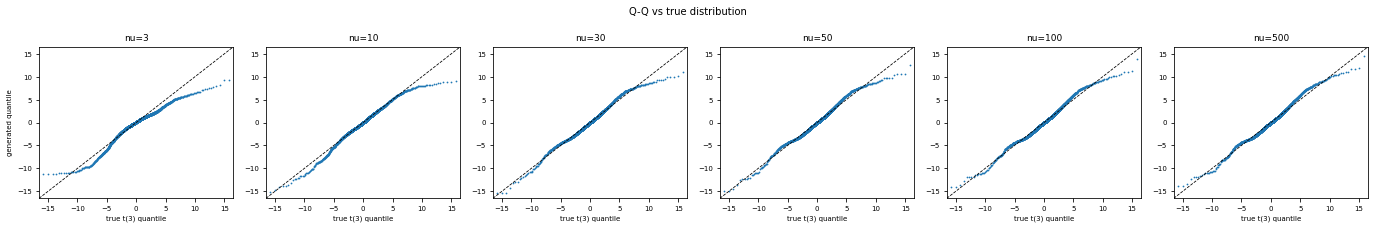

In [9]:
fig, axes = plt.subplots(1, ncol, figsize=(3.2 * ncol, 3.2))
axes = np.atleast_1d(axes)
for ax, k in zip(axes, keys):
    g = np.sort(np.asarray(gens[k], dtype=np.float64))
    p = (np.arange(len(g)) + 0.5) / len(g)
    q = stats.t.ppf(p, NU_DATA, LOC, SCALE)
    lim = float(np.nanpercentile(np.abs(q), 99.9)) * 1.3
    ax.plot(q, g, ".", ms=1.5)
    ax.plot([-lim, lim], [-lim, lim], "k--", lw=0.8)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_title(k, fontsize=9)
    ax.set_xlabel(f"true t({NU_DATA:g}) quantile", fontsize=7)
    ax.tick_params(labelsize=7)
axes[0].set_ylabel("generated quantile", fontsize=7)
fig.suptitle("Q-Q vs true distribution", fontsize=10)
fig.tight_layout()
plt.show()

### 5-4. 꼬리 생존함수

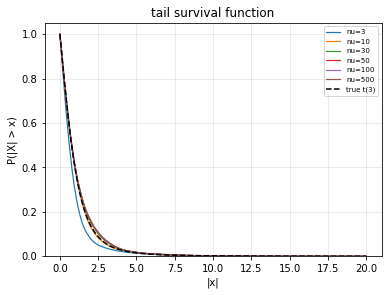

In [10]:
fig, ax = plt.subplots(figsize=(5.5, 4.2))
xs = np.linspace(0, 20, 200)
for k in keys:
    a = np.abs(np.asarray(gens[k], dtype=np.float64))
    ax.plot(xs, [np.mean(a > x) for x in xs], lw=1.2, label=k)
ax.plot(xs, 2 * stats.t.sf(xs, NU_DATA, LOC, SCALE), "k--", lw=1.5,
          label=f"true t({NU_DATA:g})")
ax.set_xlabel("|x|")
ax.set_ylabel("P(|X| > x)")
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
ax.legend(fontsize=7)
ax.set_title("tail survival function")
fig.tight_layout()
plt.show()